In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
autoencoder = pd.read_csv("/kaggle/input/datasets/samyukthaanand/comparison/autoencoder_results.csv")

iso = pd.read_csv("/kaggle/input/datasets/samyukthaanand/comparison/if_results.csv")

print("Autoencoder shape:", autoencoder.shape)
print("Isolation Forest shape:", iso.shape)

Autoencoder shape: (200000, 4)
Isolation Forest shape: (200000, 4)


In [3]:
comparison = autoencoder.merge(
    iso,
    on=["MEMBER_ID","TXN_NUM"],
    how="inner"
)

print("Merged dataset:", comparison.shape)

comparison.head()

Merged dataset: (200000, 6)


,MEMBER_ID,TXN_NUM,anomaly_score,is_anomaly,anomaly_score_if,is_anomaly_if
0,67666,168454,0.136347,False,0.066855,0
1,102660,196137,0.331936,True,0.032672,0
2,128812,108372,0.198065,False,0.062163,0
3,94357,813,0.523209,True,-0.008843,1
4,47342,49404,0.194322,False,0.055819,0


In [4]:
ae_anomalies = comparison["is_anomaly"].sum()

iso_anomalies = comparison["is_anomaly_if"].sum()

print("Autoencoder anomalies:", ae_anomalies)
print("Isolation Forest anomalies:", iso_anomalies)

Autoencoder anomalies: 10000
Isolation Forest anomalies: 10000


In [5]:
agreement = (
    comparison["is_anomaly"] ==
    comparison["is_anomaly_if"]
).mean()

print("Model agreement:", round(agreement*100,2), "%")

Model agreement: 94.71 %


In [6]:
confusion = pd.crosstab(
    comparison["is_anomaly"],
    comparison["is_anomaly_if"],
    rownames=["Autoencoder"],
    colnames=["Isolation Forest"]
)

confusion

Isolation Forest,0,1
Autoencoder,,
False,184709,5291
True,5291,4709


In [7]:
disagreement = comparison[
    comparison["is_anomaly"] != comparison["is_anomaly_if"]
]

print("Disagreement rows:", disagreement.shape)

disagreement.head(20)

Disagreement rows: (10582, 6)


,MEMBER_ID,TXN_NUM,anomaly_score,is_anomaly,anomaly_score_if,is_anomaly_if
1,102660,196137,0.331936,True,0.032672,0
6,90212,171722,0.353842,True,0.005511,0
16,7955,22521,0.394922,True,0.039932,0
25,67934,64213,0.355267,True,0.001102,0
28,100245,180143,0.272330,False,-0.001312,1
30,136045,97519,0.421493,True,0.016414,0
98,47004,143260,0.281638,False,-0.036311,1
101,57208,2674,0.241657,False,-0.036987,1
114,79209,159227,0.343835,True,0.060609,0
147,165879,918,0.105264,False,-0.029773,1


In [8]:
summary = pd.DataFrame({
    "Model":[
        "Autoencoder",
        "Isolation Forest"
    ],
    "Anomalies Detected":[
        comparison["is_anomaly"].sum(),
        comparison["is_anomaly_if"].sum()
    ],
    "Percentage":[
        comparison["is_anomaly"].mean()*100,
        comparison["is_anomaly_if"].mean()*100
    ]
})

summary

,Model,Anomalies Detected,Percentage
0,Autoencoder,10000,5.0
1,Isolation Forest,10000,5.0


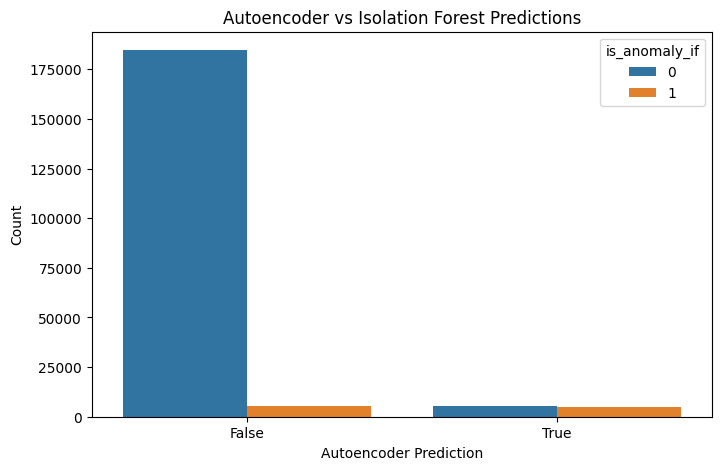

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="is_anomaly",
    hue="is_anomaly_if",
    data=comparison
)

plt.xlabel("Autoencoder Prediction")
plt.ylabel("Count")

plt.title("Autoencoder vs Isolation Forest Predictions")

plt.show()

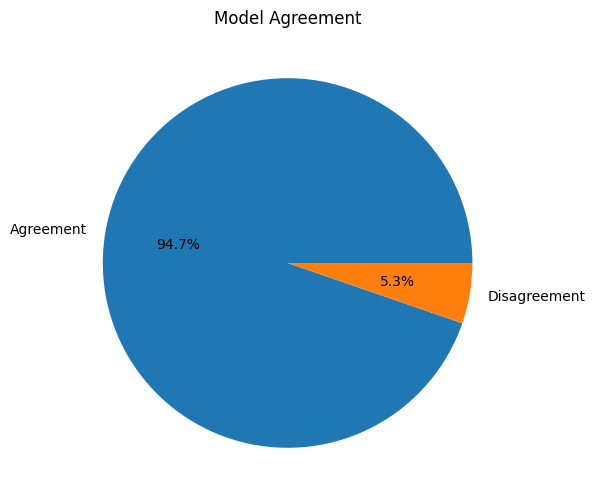

In [10]:
agreement = (comparison["is_anomaly"] == comparison["is_anomaly_if"]).sum()
disagreement = len(comparison) - agreement

plt.figure(figsize=(6,6))

plt.pie(
    [agreement, disagreement],
    labels=["Agreement","Disagreement"],
    autopct="%1.1f%%"
)

plt.title("Model Agreement")

plt.show()

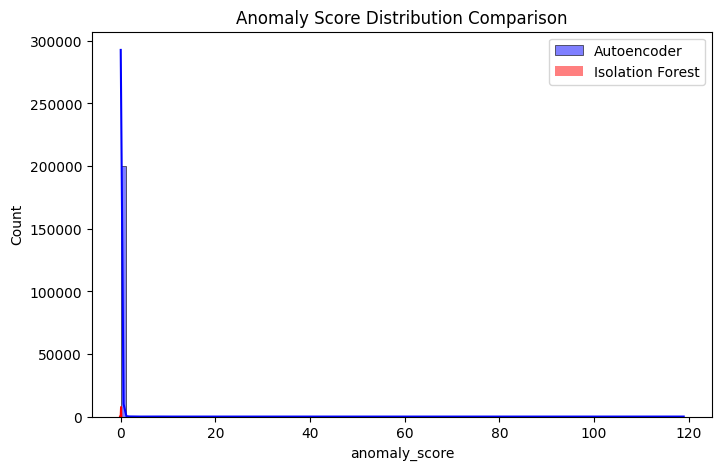

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    comparison["anomaly_score"],
    bins=100,
    color="blue",
    label="Autoencoder",
    kde=True
)

sns.histplot(
    comparison["anomaly_score_if"],
    bins=100,
    color="red",
    label="Isolation Forest",
    kde=True
)

plt.legend()
plt.title("Anomaly Score Distribution Comparison")

plt.show()

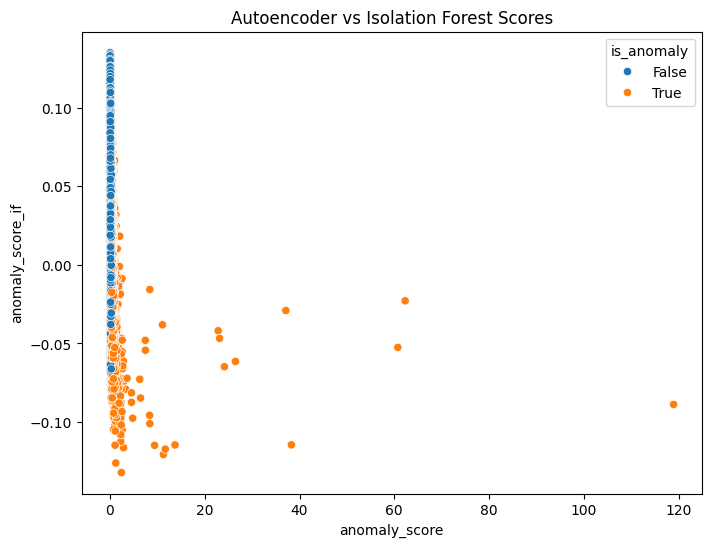

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="anomaly_score",
    y="anomaly_score_if",
    hue="is_anomaly",
    data=comparison
)

plt.title("Autoencoder vs Isolation Forest Scores")

plt.show()